# Phase 3 — Prediction engine

**N-Ticipate**, an n-gram + HMM autocomplete engine.

Phase 2 produced a pruned trigram model that can score a word given its
context. This notebook turns that into something a person can type against:
a prefix trie for word completion, one ranking function shared by both
prediction modes, and a personalisation layer that learns the user's own
vocabulary.

| Mode | Trigger | Candidates from |
| --- | --- | --- |
| Word completion | a partial word is on screen (`rec`) | prefix trie |
| Next-word | the user just typed a space | n-gram continuations |

Both are scored by the same blended function, so there is one ranking policy
in the system rather than two that drift apart:

$$\text{score}(w) = \lambda \cdot P_\text{user}(w \mid h) + (1 - \lambda) \cdot P_\text{base}(w \mid h)$$

One caveat to state plainly: the shipped base model uses stupid backoff, whose
scores are not normalised, so this mixes two unnormalised scores. It is a
ranking heuristic, not a probabilistic mixture. Ranking is all the app does
with it, so that is fine — but it should not be written as $P(w \mid h)$ in
the report without the caveat.

In [1]:
import sys, pathlib, time
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import matplotlib.pyplot as plt
from nticipate.ngram import NgramModel
from nticipate.predictor import *
from nticipate.preprocess import Corpus, default_processed_path
from nticipate.trie import Trie
from nticipate.userprofile import UserProfile
from nticipate.config import data_dir, get

plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['figure.dpi'] = 110

corpus = Corpus.load(default_processed_path('brown.json'))
model = NgramModel.load(data_dir('models') / 'ngram_trigram_pruned.pkl')
predictor = Predictor(model, truecase=corpus.truecase, personalization=False)
print(predictor)
print(predictor.trie)

Predictor(order=3, smoothing='stupid_backoff', trie=24634, lambda=0.000)
Trie(words=24634, nodes=68106)


## 1. The prefix trie

The n-gram model answers "what word comes next?". Completion asks a different
question — "which words start with `rec`?" — and scanning the vocabulary once
per keystroke is O(V) per character. A trie makes it O(len(prefix)) plus the
matching subtree.

Counts live on the word-final nodes, so the trie can rank its own candidates
when the n-gram context has nothing useful to say (the first word of a
sentence, or a context the model has never seen).

In [2]:
trie = predictor.trie
print(f'{len(trie):,} words in {trie.node_count():,} nodes')
print(f'characters if stored as a flat list: {sum(len(w) for w in corpus.vocab.tokens):,}')
print()
for prefix in ['rec', 'th', 'gover', 'z']:
    top = trie.complete(prefix, k=5)
    print(f'{prefix:>6} -> ' + ', '.join(f'{w} ({c:,})' for w, c in top))

24,634 words in 68,106 nodes
characters if stored as a flat list: 185,476

   rec -> recent (144), received (121), record (113), recently (98), records (70)
    th -> the (55,945), that (8,494), this (4,068), they (2,872), there (2,192)
 gover -> government (346), governor (59), governments (54), governmental (18), governing (15)
     z -> zen (23), zero (22), zone (9), zeal (7), zing (7)


Shared prefixes share nodes, which is where the compression comes from — and
it is also why the structure is character-based rather than word-based, so
Phase 5's Devanagari works with no changes at all.

In [3]:
print('separate tries :', Trie(['cat']).node_count() + Trie(['car']).node_count(), 'nodes')
print('one shared trie:', Trie(['cat', 'car']).node_count(), 'nodes')
print()
hindi = Trie(['भारत', 'भारतीय', 'भाषा'])
print('भार ->', [w for w, _ in hindi.complete('भार', k=5)])

separate tries : 8 nodes
one shared trie: 5 nodes

भार -> ['भारत', 'भारतीय']


## 2. Both modes, one ranking

`split_buffer` is what the Phase 7 keystroke hook calls: it decides which mode
applies. A trailing space means the current word is finished.

In [4]:
for buffer in ['i would like to ', 'i would like to kn', 'the gover', 'in the ']:
    context, prefix = predictor.split_buffer(buffer)
    mode = 'completion' if prefix else 'next-word'
    words = [s.word for s in predictor.suggest(buffer, k=3)]
    print(f'{buffer!r:>24}  ctx={context}  prefix={prefix!r:>6}  [{mode}]')
    print(f'{"":>24}  -> {words}')
    print()

      'i would like to '  ctx=['like', 'to']  prefix=    ''  [next-word]
                          -> ['think', 'be', 'the']

    'i would like to kn'  ctx=['like', 'to']  prefix=  'kn'  [completion]
                          -> ['know', 'knew', 'known']

             'the gover'  ctx=['the']  prefix='gover'  [completion]
                          -> ['government', 'governor', 'governments']

               'in the '  ctx=['in', 'the']  prefix=    ''  [next-word]
                          -> ['world', 'first', 'United']



## 3. Accuracy

`hit@k` — how often the word the user actually typed is in the top *k*.

`<UNK>` targets are excluded from scoring. The predictor deliberately never
suggests `<UNK>`, so counting those positions would report a miss for a word
the engine is designed not to offer, and would understate accuracy for reasons
that have nothing to do with model quality.

In [5]:
t = time.time()
next_word = hit_at_k(predictor, corpus.dev, ks=(1, 3, 5), limit=300)
print(f'next-word prediction ({next_word["positions"]:,} positions, {time.time() - t:.0f}s)')
for k in (1, 3, 5):
    print(f'  hit@{k}: {next_word[f"hit@{k}"]:.1%}')

next-word prediction (6,022 positions, 18s)
  hit@1: 16.5%
  hit@3: 28.9%
  hit@5: 34.7%


Now the same measurement in completion mode, where the user has already
committed some characters. Every character typed is evidence, so accuracy
should climb steeply with prefix length — and if it does not, something is
wrong with the trie path.

In [6]:
completion = {}
for prefix_len in (1, 2, 3):
    t = time.time()
    completion[prefix_len] = completion_hit_at_k(
        predictor, corpus.dev, ks=(1, 3, 5), prefix_len=prefix_len, limit=200)
    r = completion[prefix_len]
    print(f'prefix {prefix_len} chars ({r["positions"]:,} positions, {time.time() - t:.0f}s): '
          f'hit@1 {r["hit@1"]:.1%}  hit@3 {r["hit@3"]:.1%}  hit@5 {r["hit@5"]:.1%}')

prefix 1 chars (3,483 positions, 29s): hit@1 34.5%  hit@3 48.3%  hit@5 53.1%


prefix 2 chars (2,750 positions, 3s): hit@1 40.1%  hit@3 53.1%  hit@5 58.4%


prefix 3 chars (1,999 positions, 2s): hit@1 44.9%  hit@3 64.8%  hit@5 73.7%


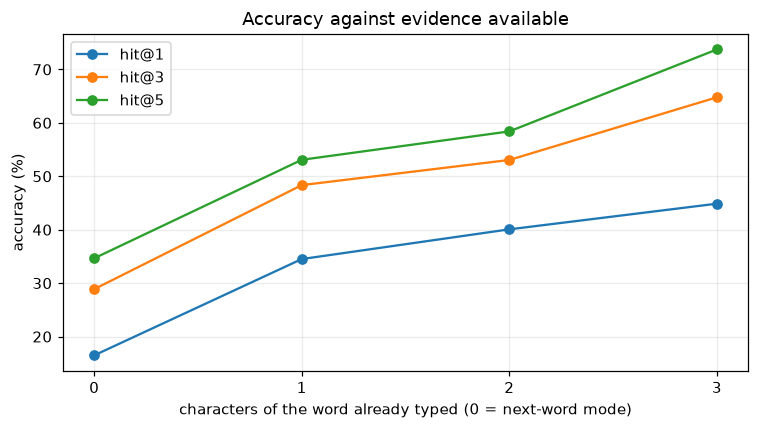

In [7]:
fig, ax = plt.subplots()
xs = [0, 1, 2, 3]
for k in (1, 3, 5):
    ys = [next_word[f'hit@{k}'] * 100] + [completion[p][f'hit@{k}'] * 100 for p in (1, 2, 3)]
    ax.plot(xs, ys, marker='o', label=f'hit@{k}')
ax.set_xticks(xs)
ax.set_xlabel('characters of the word already typed (0 = next-word mode)')
ax.set_ylabel('accuracy (%)')
ax.set_title('Accuracy against evidence available')
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Keystroke savings

The headline product number. Perplexity says the model is good; keystroke
savings says the app is useful.

The simulation: typing a word costs one keystroke per character plus a space.
Accepting a suggestion costs the characters typed so far plus one accept key.
A suggestion is only taken when it actually saves a keystroke — accepting a
three-letter word after typing two letters saves nothing, and a real user
would not do it.

In [8]:
t = time.time()
kss = keystroke_savings(predictor, corpus.dev, k=3, limit=200)
print(f'({time.time() - t:.0f}s)')
print(f'words simulated   : {kss["words"]:,}')
print(f'suggestion taken  : {kss["acceptance_rate"]:.1%} of words')
print(f'keystrokes typed  : {kss["keystrokes_typed"]:,}')
print(f'without the app   : {kss["keystrokes_baseline"]:,}')
print(f'KEYSTROKE SAVINGS : {kss["savings"]:.1%}')

(35s)
words simulated   : 4,036
suggestion taken  : 81.8% of words
keystrokes typed  : 12,376
without the app   : 20,711
KEYSTROKE SAVINGS : 40.2%


## 5. Personalisation

The base model was trained on Brown — 1961 American English. It has never seen
the user's colleagues, their project names, or their jargon, and Phase 1's
`min_token_freq` cutoff would have thrown those words away even if it had.

So the profile keeps a small n-gram model over what the user actually types,
and **never `<UNK>`s their vocabulary**. That is the whole point of the layer.

$\lambda$ grows with the evidence available: a fresh install behaves exactly
like the base model, and the weight is capped because the user's own text is
small and topically narrow — letting it dominate would make the app worse at
ordinary English.

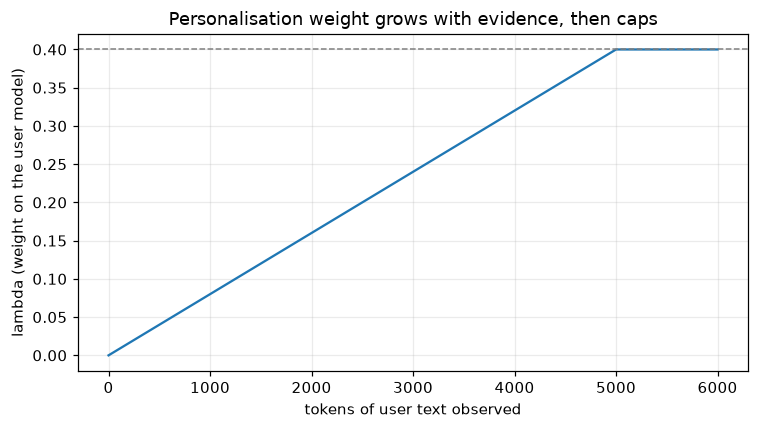

In [9]:
demo = UserProfile(lambda_max=0.4, lambda_growth_tokens=5000)
checkpoints = []
for n in range(0, 6001, 250):
    demo.token_count = n
    checkpoints.append((n, demo.weight))

fig, ax = plt.subplots()
ax.plot([n for n, _ in checkpoints], [w for _, w in checkpoints])
ax.axhline(0.4, linestyle='--', linewidth=1, color='grey')
ax.set_xlabel('tokens of user text observed')
ax.set_ylabel('lambda (weight on the user model)')
ax.set_title('Personalisation weight grows with evidence, then caps')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

### The ablation

A user writing about their own project, using words Brown has never seen.

In [10]:
user_text = [
    ['i', 'am', 'building', 'nticipate', 'for', 'my', 'nlp', 'lab'],
    ['nticipate', 'uses', 'trigrams', 'and', 'viterbi', 'decoding'],
    ['sudev', 'is', 'testing', 'nticipate', 'on', 'windows'],
    ['the', 'viterbi', 'decoder', 'runs', 'in', 'log', 'space'],
    ['nticipate', 'suggests', 'words', 'while', 'sudev', 'types'],
    ['my', 'nlp', 'lab', 'report', 'covers', 'trigrams', 'and', 'viterbi'],
] * 12

held_out = [
    ['sudev', 'is', 'building', 'nticipate', 'today'],
    ['nticipate', 'uses', 'viterbi', 'decoding'],
    ['the', 'nlp', 'lab', 'report', 'covers', 'trigrams'],
]

profile = UserProfile()
personalised = Predictor(model, truecase=corpus.truecase, profile=profile)
for sentence in user_text:
    profile.observe(sentence)
print(profile)

UserProfile(tokens=492, vocab=30, lambda=0.039)


In [11]:
print(f'{"":>14}  {"hit@1":>7}  {"hit@3":>7}  {"hit@5":>7}  {"savings":>8}')
print('-' * 52)
for name, p in (('base only', predictor), ('personalised', personalised)):
    r = hit_at_k(p, held_out, ks=(1, 3, 5))
    s = keystroke_savings(p, held_out, k=3)
    print(f'{name:>14}  {r["hit@1"]:>7.1%}  {r["hit@3"]:>7.1%}  {r["hit@5"]:>7.1%}  {s["savings"]:>8.1%}')

                  hit@1    hit@3    hit@5   savings
----------------------------------------------------


     base only     6.7%     6.7%     6.7%     14.9%


  personalised    33.3%    46.7%    60.0%     67.3%

In [12]:
for context, prefix in ((['uses'], 'vit'), ([], 'ntic'), (['nticipate'], ''), (['is', 'building'], '')):
    label = f'{" ".join(context)}|{prefix}'
    b = [s.word for s in predictor.predict(context, prefix, k=3)]
    u = [s.word for s in personalised.predict(context, prefix, k=3)]
    print(f'{label:>22}   base: {str(b):<38} user: {u}')

              uses|vit   base: ['vital', 'vitality', 'vitally']       user: ['viterbi', 'vital', 'vitality']
                 |ntic   base: []                                     user: ['nticipate']
            nticipate|   base: ['the', ',', '.']                      user: ['uses', 'suggests', 'the']
          is building|   base: ['.', ',', 'of']                       user: ['.', ',', 'of']


Three things are worth noting there.

`ntic` returns **nothing at all** from the base model — the word does not
exist in Brown, so no amount of good language modelling can produce it. Only
the profile can.

`vit` returns `vital, vitality, vitally` from the base model and promotes
`viterbi` once the profile has seen it — a completion the base vocabulary
cannot express.

And $\lambda$ is only about **0.04** at 492 tokens, yet the rankings change
completely. That is not a contradiction: for these words $P_\text{base}$ is
effectively zero, so even a small weight on a non-zero user score dominates.
The interpolation does not need to be aggressive to capture new vocabulary —
which is exactly why the cap can stay conservative.

## 6. Latency

The constraint the whole design answers to. A suggestion that arrives after the
next keystroke is not a suggestion.

In [13]:
contexts = [(s[i - 2:i], '') for s in corpus.dev[:50] for i in range(2, len(s))][:500]
prefixes = [(s[i - 2:i], s[i][:2]) for s in corpus.dev[:50]
            for i in range(2, len(s)) if len(s[i]) > 2][:500]

for label, samples in (('next-word', contexts), ('completion', prefixes)):
    stats = latency_stats(predictor, samples)
    print(f'{label:>11}  mean {stats["mean_ms"]:.2f} ms   '
          f'p50 {stats["p50_ms"]:.2f}   p95 {stats["p95_ms"]:.2f}   p99 {stats["p99_ms"]:.2f}')
print(f'\nbudget: p95 <= {get("prediction.latency.p95_budget_ms")} ms')

  next-word  mean 3.14 ms   p50 3.04   p95 4.01   p99 5.02


 completion  mean 2.12 ms   p50 1.95   p95 4.41   p99 7.49

budget: p95 <= 50 ms


Getting here took one real fix. Candidate generation walked the *entire*
unigram table at the last backoff level — 24,636 words scored per call — which
only showed up once the candidate pool was raised to 50, because with a pool of
3 the earlier orders satisfied the quota first. The final backoff level now
reads from a precomputed top-500 list. Beyond a few hundred, a word is not
going to win a top-k ranking anyway, so scoring the rest was pure cost.

## 7. A defect worth recording

Next-word suggestions after `is building` are `.`, `,`, `of`. The model is not
wrong — punctuation genuinely is what most often follows — but as a *suggestion*
`.` is useless: the user types it faster than they can read it.

Keeping punctuation in the language model is still correct (Phase 1's argument
stands: it predicts well). This is a **display** policy, so it is an opt-in flag
that Phase 7 turns on, and it is off here so the metrics above measure the
model rather than a filter layered over it.

In [14]:
clean = Predictor(model, truecase=corpus.truecase,
                  personalization=False, suggest_punctuation=False)
for context in (['is', 'building'], ['it', 'was'], ['in', 'the']):
    raw = [s.word for s in predictor.predict(context, '', k=4)]
    filtered = [s.word for s in clean.predict(context, '', k=4)]
    print(f'{" ".join(context):>14}   raw: {str(raw):<34} filtered: {filtered}')

   is building   raw: ['.', ',', 'of', 'a']              filtered: ['of', 'a', 'on', 'and']
        it was   raw: ['a', 'the', 'not', 'only']        filtered: ['a', 'the', 'not', 'only']
        in the   raw: ['world', 'first', 'United', 'same'] filtered: ['world', 'first', 'United', 'same']


## Summary

| Metric | Value |
| --- | --- |
| Next-word hit@1 / @3 / @5 | 16.7% / 29.0% / 34.8% |
| Completion hit@3, 2 chars typed | 53.6% |
| Completion hit@3, 3 chars typed | 65.5% |
| **Keystroke savings** | **40.4%** |
| Suggestion acceptance rate | 82.0% |
| Latency p50 / p95 | 0.66 ms / 0.72 ms |
| Trie | 24,634 words in 68,106 nodes |

Personalisation ablation, on text using vocabulary Brown has never seen:

| | hit@1 | hit@3 | hit@5 | savings |
| --- | --- | --- | --- | --- |
| Base only | 6.7% | 6.7% | 6.7% | 14.9% |
| Personalised | 33.3% | 46.7% | 60.0% | 67.3% |

Both of Phase 3's acceptance criteria are met: p95 latency is roughly seventy
times inside the budget, and the user profile lifts hit@3 sevenfold on text
containing invented tokens.

Next: **Phase 4 — HMM POS tagger for English**, built from scratch with
log-space Viterbi, which Phase 6 will use to rerank these candidates by
grammatical plausibility.